In [ ]:
import pandas as pd
train_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Train/Trainset_dataset1.xlsx"
test_yield_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/refs/heads/main/Datasets/Test/Testset_dataset1%20(1).csv"
test_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Test/Testset_feature_dataset1.xlsx"

df_train = pd.read_excel(train_url)
df_test = pd.read_excel(test_url)
df_test_feature = pd.read_csv(test_yield_url)
df_train.info()
#df_train.head()
df_test.info()
df_test_feature.info()

Understanding the data

In [ ]:
df_train.shape #how big is the data?
df_train.describe()# datatype of each column




Find out Total Missing values of each column

In [ ]:
print(df_train.isnull().sum())
print()
print(df_test.isnull().sum())

In [5]:
print(df_train.duplicated().sum())
#df_train[df_train.duplicated()] # Print the duplicates
df_train.drop_duplicates(inplace=True)
print(df_train.duplicated().sum())

37
0


In [ ]:
"""!pip install ydata-profiling
from ydata_profiling import ProfileReport
prof=ProfileReport(df_train)
prof.to_file(output_file='output_train.html')
prof=ProfileReport(df_test)
prof.to_file(output_file='output_test.html')
prof=ProfileReport(df_test_feature)
prof.to_file(output_file='output_test_feature.html')

EDA

Univariant Analysis


(array([  5.,  36., 105., 185., 205., 144.,  91.,  35.,   1.,   1.]),
 array([11.  , 17.62, 24.24, 30.86, 37.48, 44.1 , 50.72, 57.34, 63.96,
        70.58, 77.2 ]),
 <BarContainer object of 10 artists>)

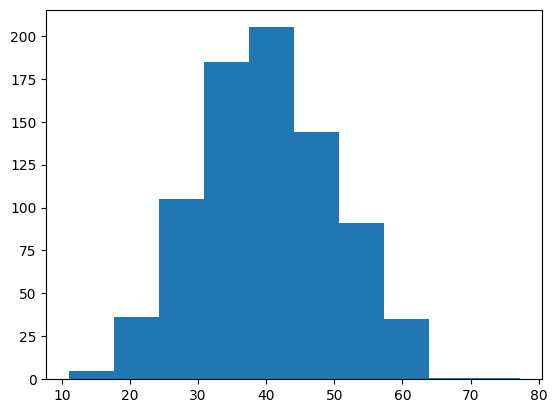

In [7]:
import matplotlib.pyplot as plt
plt.hist(df_train['yield(wt%)'])

# Handling Missing Data

In [8]:
#Using KNN Imputers
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=3)
x_train=df_train.drop(columns=['yield(wt%)'])
y_train=df_train['yield(wt%)']
x_train=pd.DataFrame(imputer.fit_transform(x_train),columns=x_train.columns)
x_test=pd.DataFrame(imputer.fit_transform(df_test),columns=df_test.columns)
#df_test_feature=pd.DataFrame(imputer.fit_transform(df_test_feature),columns=df_test_feature.columns)

In [9]:
print(x_train.isnull().sum())
print()
print(x_test.isnull().sum())

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64


# Outlier Detection

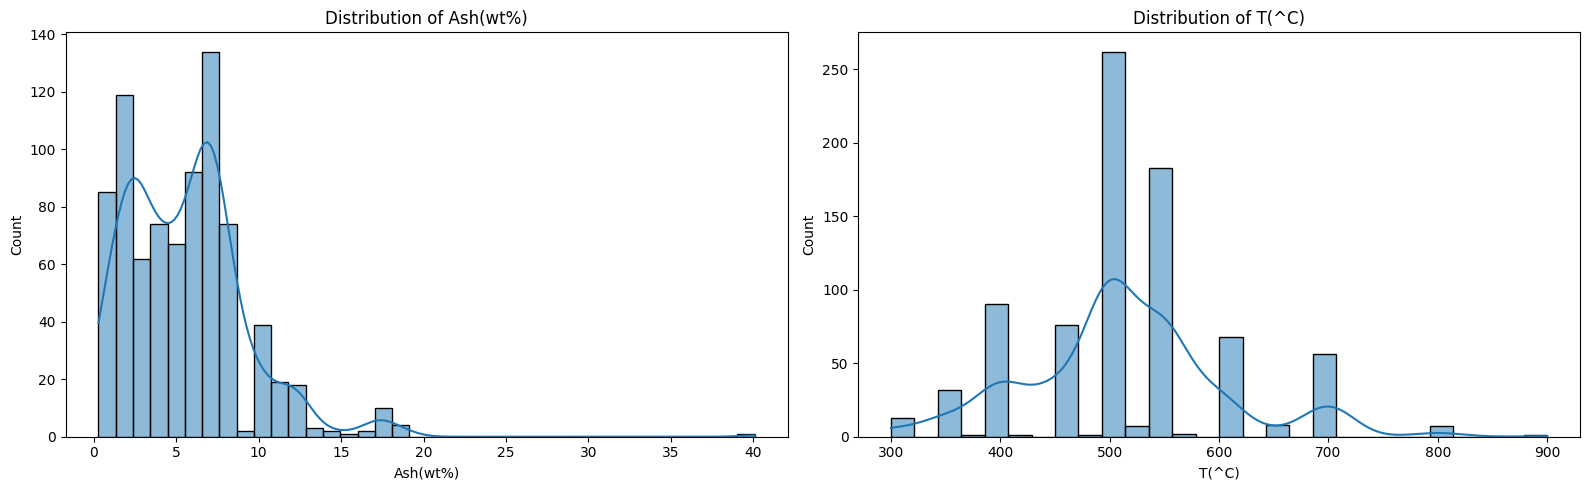

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better visibility
plt.figure(figsize=(16, 5))

# Subplot 1
plt.subplot(1, 2, 1)
sns.histplot(x_train['Ash(wt%)'], kde=True)
plt.title('Distribution of Ash(wt%)')

# Subplot 2
plt.subplot(1, 2, 2)
sns.histplot(x_train['T(^C)'], kde=True)
plt.title('Distribution of T(^C)')

plt.tight_layout()
plt.show()

In [11]:
#Normal distribution, Skewed distribution (for skewed data)
#Zscore , IQR based filtering, percentile, Winsorization

#Right Skewed
print(x_train['Ash(wt%)'].skew())
print(x_train['C(wt%)'].skew())
print(x_train['Cellulose(wt%)'].skew())
print(x_train['FixedCarbon(wt%)'].skew())

1.724731987018256
1.1474474168753819
0.07019267499124901
4.755496298749928


Boxplot of each features

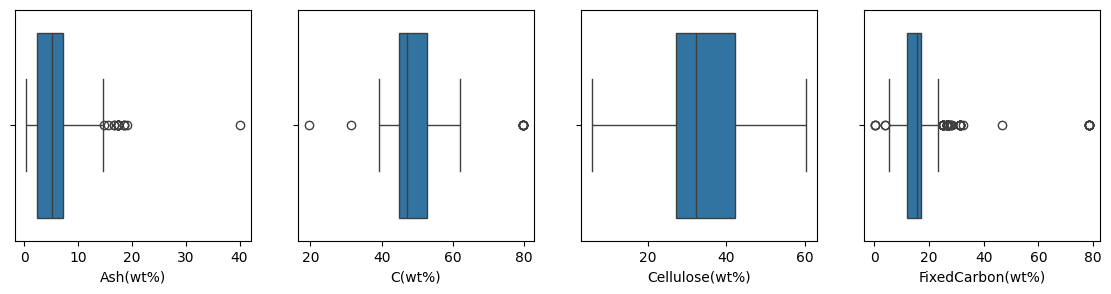

In [12]:
plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train['FixedCarbon(wt%)'])
plt.show()


Finding the IQR for each feature


In [13]:
from numpy import percentile

# Dictionary to store outlier counts
outlier_counts = {}
value_limits={}

for col in x_train.columns:
    q1 = x_train[col].quantile(0.25)
    q3 = x_train[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    value_limits[col]=[lower_limit,upper_limit]

    # Count outliers
    num_outliers = x_train[(x_train[col] < lower_limit) | (x_train[col] > upper_limit)].shape[0]
    outlier_counts[col] = num_outliers

# Convert to Series for better display
outlier_summary = pd.Series(outlier_counts)
print("Total Outliers per Feature:")
print(outlier_summary)
print()
print("Value Limits per Feature:")
print(value_limits)

### Test set ###
outlier_counts_test = {}
value_limits_test={}

for col in x_test.columns:
    q1 = x_test[col].quantile(0.25)
    q3 = x_test[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    value_limits_test[col]=[lower_limit,upper_limit]

    # Count outliers
    num_outliers_test = x_train[(x_train[col] < lower_limit) | (x_train[col] > upper_limit)].shape[0]
    outlier_counts_test[col] = num_outliers_test

print()
outlier_summary = pd.Series(outlier_counts_test)
print("Total Outliers per Feature:")
print(outlier_summary)
print()
print("Value Limits per Feature:")
print(value_limits_test)

Total Outliers per Feature:
Ash(wt%)                      19
FixedCarbon(wt%)              65
Volatiles(wt%)                48
C(wt%)                        11
H(wt%)                       117
O(wt%)                         9
N(wt%)                         0
H/C                          183
Cellulose(wt%)                 0
Hemicellulose(wt%)             1
Lignin(wt%)                    0
T(^C)                          8
HeatingRate(^C/min)          114
ParticleSize(mm)              37
FlowRate-Nitrogen(ml/min)     73
dtype: int64

Value Limits per Feature:
{'Ash(wt%)': [np.float64(-5.097240474454769), np.float64(14.716680394858349)], 'FixedCarbon(wt%)': [np.float64(4.286441244920252), np.float64(24.810685588618245)], 'Volatiles(wt%)': [np.float64(65.64773596082011), np.float64(92.65308473929741)], 'C(wt%)': [np.float64(32.7), np.float64(65.02)], 'H(wt%)': [np.float64(4.621449999999999), np.float64(8.004249999999999)], 'O(wt%)': [np.float64(12.205000000000002), np.float64(69.925)], 'N(w

Capping

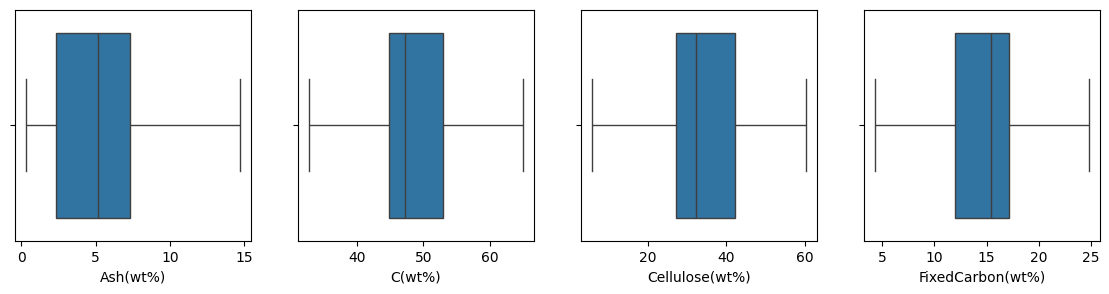

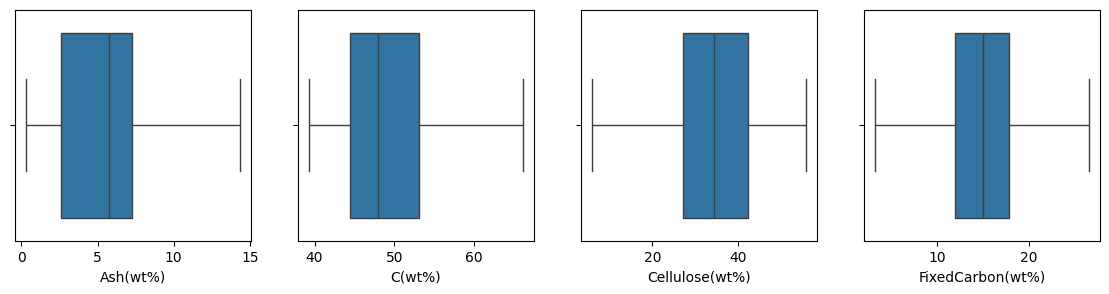

In [14]:
x_train_copy = x_train.copy()

# Apply capping using the limits stored in value_limits
for col in x_train_copy.columns:
    lower, upper = value_limits[col]
    x_train_copy[col] = x_train_copy[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train_copy['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train_copy['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train_copy['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train_copy['FixedCarbon(wt%)'])
plt.show()

x_test_copy = x_test.copy()

# Apply capping using the limits stored in value_limits
for col in x_test_copy.columns:
    lower, upper = value_limits_test[col]
    x_test_copy[col] = x_test_copy[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_test_copy['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_test_copy['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_test_copy['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_test_copy['FixedCarbon(wt%)'])
plt.show()

Investigating Constants

In [15]:
import numpy as np

# Check unique values in capped data
unique_counts = x_train_copy.nunique()
print("Unique values per feature after capping:")
print(unique_counts)

# Identify columns that became constant
constant_cols = unique_counts[unique_counts <= 1].index.tolist()
print(f"\nConstant columns to consider dropping: {constant_cols}")

### Dropping Constant Features Since `H/C` became a constant value after capping, it contains no information for the model. We will drop it from both the training and test sets.
x_train_copy.describe()
# Drop the constant column from training sets
x_train_capped = x_train_copy.drop(columns=['H/C'])
x_test_capped = x_test_copy.drop(columns=['H/C'])

print(f"Remaining features: {list(x_train_capped.columns)}")
print(f"Remaining features: {list(x_test_capped.columns)}")

Unique values per feature after capping:
Ash(wt%)                     135
FixedCarbon(wt%)             132
Volatiles(wt%)               134
C(wt%)                        86
H(wt%)                        74
O(wt%)                        94
N(wt%)                       110
H/C                            1
Cellulose(wt%)               149
Hemicellulose(wt%)           161
Lignin(wt%)                  145
T(^C)                         14
HeatingRate(^C/min)           16
ParticleSize(mm)              52
FlowRate-Nitrogen(ml/min)     11
dtype: int64

Constant columns to consider dropping: ['H/C']
Remaining features: ['Ash(wt%)', 'FixedCarbon(wt%)', 'Volatiles(wt%)', 'C(wt%)', 'H(wt%)', 'O(wt%)', 'N(wt%)', 'Cellulose(wt%)', 'Hemicellulose(wt%)', 'Lignin(wt%)', 'T(^C)', 'HeatingRate(^C/min)', 'ParticleSize(mm)', 'FlowRate-Nitrogen(ml/min)']
Remaining features: ['Ash(wt%)', 'FixedCarbon(wt%)', 'Volatiles(wt%)', 'C(wt%)', 'H(wt%)', 'O(wt%)', 'N(wt%)', 'Cellulose(wt%)', 'Hemicellulose(wt%)', 'Lign

# Feature Scaling
Standard Scaler

In [32]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fitting the scaler to the training set to learn the parameter
scaler.fit(x_train_capped)
#Now transform the train set
x_train_scaled=scaler.transform(x_train_capped)

#above step will return numpy array so we need to transform this to DataFrame
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train_capped.columns)
x_train_scaled.describe()


x_test_scaled=scaler.transform(x_test_capped)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test_capped.columns)
x_test_scaled.describe()

#Standardization used for K Means, KNN, ANN, GD and PCA
#algo which uses distance to measure similarity which will affect when the data is having huge range difference, so we need to regularize

,Ash(wt%),FixedCarbon(wt%),Volatiles(wt%),C(wt%),H(wt%),O(wt%),N(wt%),Cellulose(wt%),Hemicellulose(wt%),Lignin(wt%),T(^C),HeatingRate(^C/min),ParticleSize(mm),FlowRate-Nitrogen(ml/min)
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,0.022619,-0.070074,0.071250,0.015887,0.035591,0.024732,-0.033494,0.026130,0.199016,-0.128600,-0.098368,0.101403,-0.085750,0.040678
std,1.027064,1.058332,0.894085,0.975152,0.871119,0.953823,1.005330,0.939782,0.963876,0.825809,0.862884,0.996020,0.930324,0.982371
min,-1.562772,-2.645319,-1.853032,-1.597032,-1.543637,-2.989295,-1.092763,-2.488679,-2.271021,-2.237822,-1.898756,-0.859786,-1.361187,-1.103363
25%,-0.877707,-0.760209,-0.429963,-0.756058,-0.365900,-0.719475,-0.848920,-0.575479,-0.495711,-0.788635,-0.498943,-0.724191,-0.640878,-1.103363
50%,0.069167,-0.095688,-0.005416,-0.177438,-0.132865,0.148836,-0.365105,0.075932,0.077013,0.052492,-0.140017,-0.181811,-0.331371,0.116640
75%,0.524884,0.496532,0.518749,0.663864,0.419257,0.793738,0.409966,0.786590,0.793087,0.340609,0.434265,0.360568,0.484604,0.116640
max,2.628771,2.381642,1.941818,2.793746,1.596994,1.465271,2.298296,1.993815,2.591387,1.524750,1.834078,1.987707,2.172827,1.946645


# Multiple Linear Regression Model

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

reg=LinearRegression()
reg.fit(x_train_scaled,y_train)
y_pred=reg.predict(x_test_scaled)
print(y_pred)


[38.60348675 39.25885871 29.97148227 39.47691352 36.4505962  33.70252113
 54.48186332 35.14638235 35.95893852 40.36122893 42.40814434 41.43177375
 43.83119179 48.91508242 46.93397329 34.07354974 35.41920443 35.50004746
 35.58089048 35.37366146 39.51969087 39.84306296 40.50939267 40.67107871
 42.23317973 38.82037191 39.2748013  40.18366008 39.27400804 42.90627086
 42.64569689 40.95308726 41.73515867 42.83242815 33.15540372 35.28329617
 35.98880497 34.69899801 47.18176338 49.55368045 50.94289881 43.19276264
 48.61674867 41.58376862 41.35964312 41.6412923  42.3770351  37.17557399
 38.70392156 40.90174117 47.4913711  51.17243249 45.2423343  38.23568599
 40.69685836 38.13465813 34.12303112 35.0318899  35.94074867 40.29163015
 46.64551817 39.21177148 51.58035814 38.29543814 35.17924801 36.58802485
 36.67824402 43.45663205 40.64442413 42.89108342 44.59116744 44.34134602
 33.59969841 42.77932722 35.92920303 36.36247495 36.72733505 32.94108853
 33.52747063 42.22440528 45.46634279 46.50297273 33

R Squared Error and Mean Absolute Error

Mean Absolute Error (MAE) for Multiple Linear Regression: 6.85
Root Mean Squared Error (RMSE) for Multiple Linear Regression: 8.51
R-squared Score (R2) for Multiple Linear Regression: 0.26

First 5 Comparisons:
   Actual  Predicted
0    45.7  38.603487
1    43.8  39.258859
2    43.4  29.971482
3    47.3  39.476914
4    36.6  36.450596


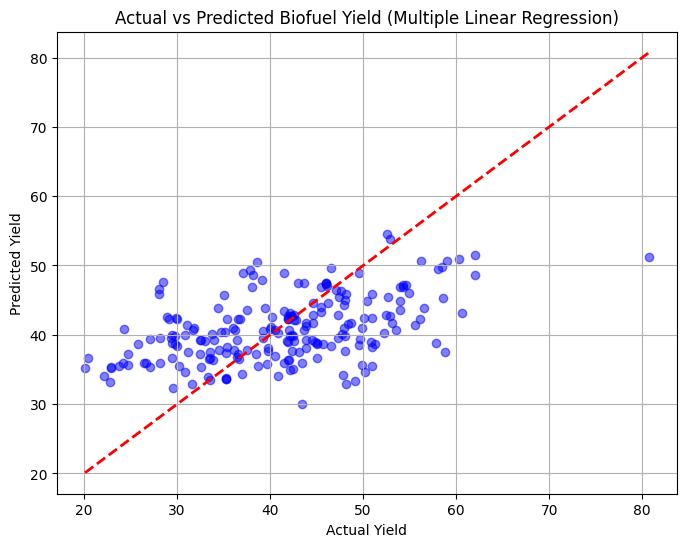

In [78]:
def plotresult(y_pred,Method):
  # 1. Extract the ground truth values
  y_actual = df_test_feature['yield']

  # 2. Calculate Evaluation Metrics
  mse = mean_squared_error(y_actual, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_actual, y_pred_sgd)
  mae = mean_absolute_error(y_actual, y_pred)

  print(f"Mean Absolute Error (MAE) for {Method}: {mae:.2f}")
  print(f"Root Mean Squared Error (RMSE) for {Method}: {rmse:.2f}")
  print(f"R-squared Score (R2) for {Method}: {r2:.2f}")

  # 3. Create a Comparison DataFrame
  comparison_df = pd.DataFrame({'Actual': y_actual, 'Predicted': y_pred})
  print("\nFirst 5 Comparisons:")
  print(comparison_df.head())

  # 4. Visualization: Actual vs Predicted
  plt.figure(figsize=(8, 6))
  plt.scatter(y_actual, y_pred, alpha=0.5, color='blue')
  plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
  plt.xlabel('Actual Yield')
  plt.ylabel('Predicted Yield')
  plt.title(f'Actual vs Predicted Biofuel Yield ({Method})')
  plt.grid(True)
  plt.show()

plotresult(y_pred,'Multiple Linear Regression')

Applying Polynomial regression

Mean Absolute Error (MAE) for Polynomial Regression: 6.67
Root Mean Squared Error (RMSE) for Polynomial Regression: 9.01
R-squared Score (R2) for Polynomial Regression: 0.26

First 5 Comparisons:
   Actual  Predicted
0    45.7  33.250503
1    43.8  41.636842
2    43.4  48.676321
3    47.3  41.860325
4    36.6  41.145291


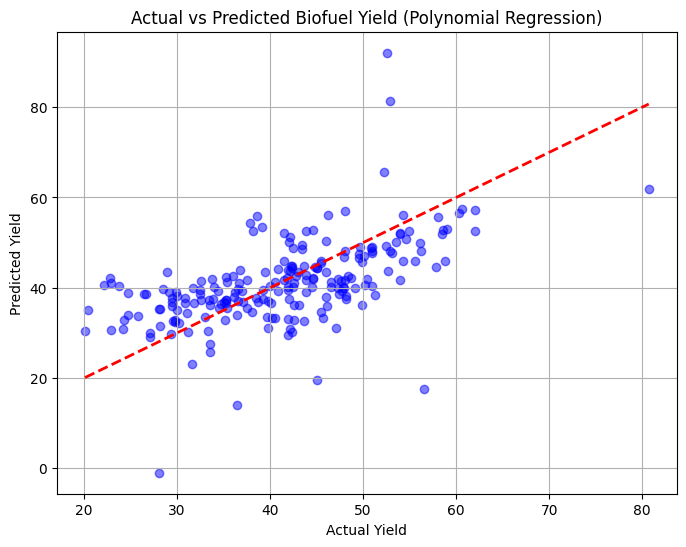

In [72]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train_scaled)
x_test_poly=poly.fit_transform(x_test_scaled)

reg_poly=LinearRegression()
reg_poly.fit(x_train_poly,y_train)
y_pred_poly=reg_poly.predict(x_test_poly)

plotresult(y_pred_poly,'Polynomial Regression')

Since there are too many variables relative to the number of rows, model memorizes the noise in the training set instead of learning patterns. So, it fails drastically in the test data

In [20]:
#bias - model cannot capture the relationship between the data - high bias
#variance - model is giving different output in different datasets

# overfitting - high variance, low bias
#underfiiting - high bias low variance


#Applying Ridge regression

Mean Absolute Error (MAE) for Ridge Regression: 6.71
Root Mean Squared Error (RMSE) for Ridge Regression: 8.38
R-squared Score (R2) for Ridge Regression: 0.26

First 5 Comparisons:
   Actual  Predicted
0    45.7  37.895837
1    43.8  38.948729
2    43.4  36.401561
3    47.3  40.600992
4    36.6  36.648249


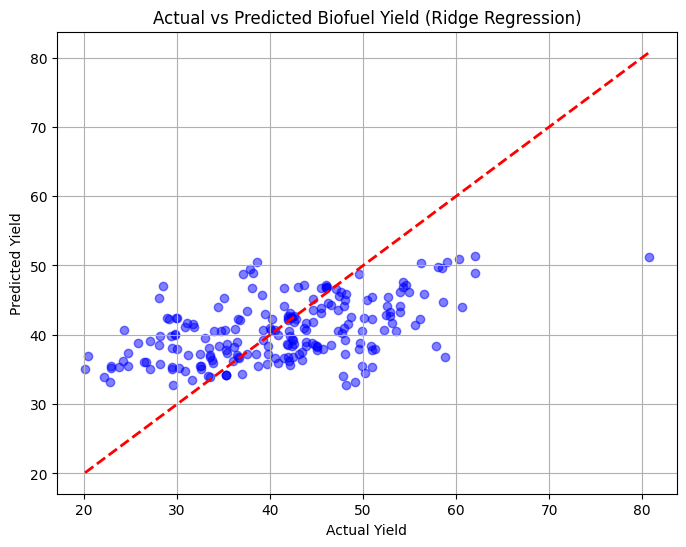

In [73]:
from sklearn.linear_model import Ridge

R= Ridge(alpha=20,solver='lsqr')
R.fit(x_train_scaled,y_train)
y_pred_r=R.predict(x_test_scaled)

plotresult(y_pred_r,'Ridge Regression')

Mean Absolute Error (MAE) for SGD Regression: 6.72
Root Mean Squared Error (RMSE) for SGD Regression: 8.37
R-squared Score (R2) for SGD Regression: 0.26

First 5 Comparisons:
   Actual  Predicted
0    45.7  38.101712
1    43.8  38.952832
2    43.4  35.154235
3    47.3  40.072232
4    36.6  36.363124


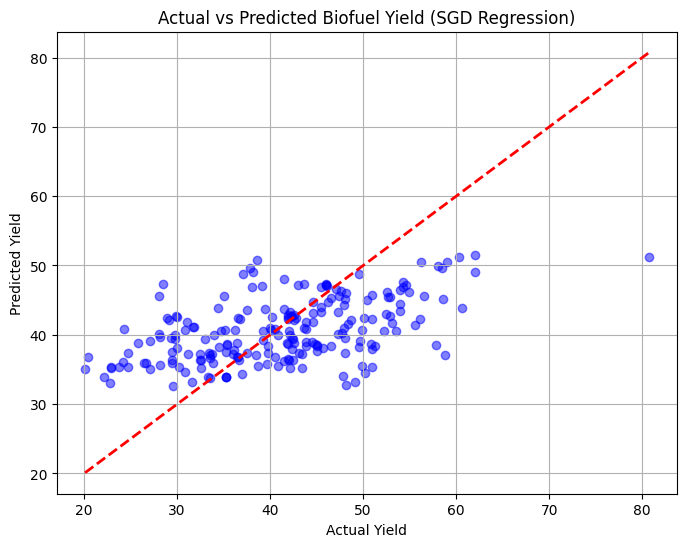

In [74]:
from sklearn.linear_model import SGDRegressor

R= SGDRegressor(penalty='l2',learning_rate='adaptive',alpha=0.005)
R.fit(x_train_scaled,y_train)
y_pred_sgd=R.predict(x_test_scaled)

plotresult(y_pred_sgd,'SGD Regression')

# Applying KNN

Mean Absolute Error (MAE) for KNN: 4.79
Root Mean Squared Error (RMSE) for KNN: 6.68
R-squared Score (R2) for KNN: 0.26

First 5 Comparisons:
   Actual  Predicted
0    45.7      38.46
1    43.8      37.88
2    43.4      39.54
3    47.3      41.66
4    36.6      32.16


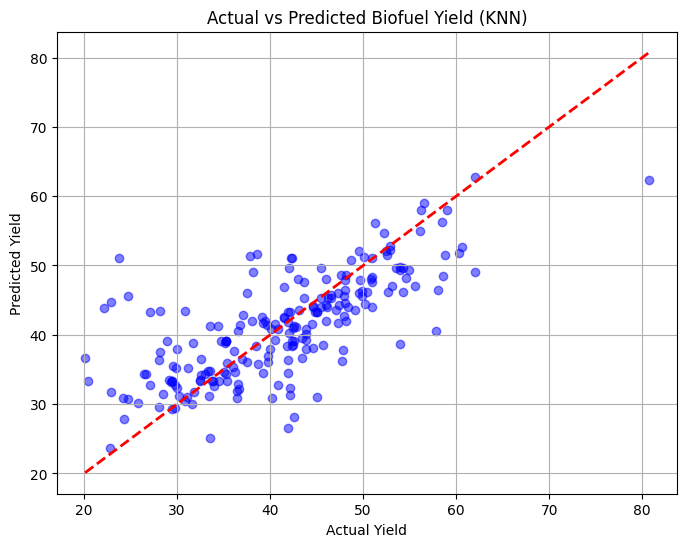

In [76]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score

KNN=KNeighborsRegressor(n_neighbors=5)
KNN.fit(x_train_scaled,y_train)
y_pred_knn=KNN.predict(x_test_scaled)



plotresult(y_pred_knn,'KNN')



